# DP2 starter notebook

Make sure you choose the **latest Weekly release** when you run this notebook on the RSP. This will give you the latest software versions with bug fixes and performance improvements.

In [40]:
import lsdb

import astropy.units as u
from astropy.coordinates import SkyCoord
from upath import UPath
import matplotlib.pyplot as plt
from lsst.utils.plotting import (get_multiband_plot_colors,
                                 get_multiband_plot_symbols)

In [2]:
# Setup
from dask.distributed import Client
client = Client(n_workers=4, memory_limit="4GiB", threads_per_worker=1)

In [15]:
base_path = UPath("/rubin/lsdb_data")

# Choose catalog
# Object catalog: "object_collection"
# DiaObject catalog: "dia_object_collection"
cat = lsdb.open_catalog(base_path / "object_collection",
# Select columns
# Column descriptions available at https://sdm-schemas.lsst.io/dp1.html
    columns=['g_psfFlux', 'g_psfFluxErr', 'r_psfFlux', 'r_psfFluxErr']
# Select a sky region
    ).cone_search(ra=38.0, dec=7, radius_arcsec=2*3600
# Query on column values
    ).query('g_psfFlux > 2.0 and r_psfFlux > 7.0')


In [16]:
# Check catalog
cat

,g_psfFlux,g_psfFluxErr,r_psfFlux,r_psfFluxErr,coord_ra,coord_dec
npartitions=59,,,,,,
"Order: 6, Pixel: 130",float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow]
"Order: 8, Pixel: 2176",...,...,...,...,...,...
...,...,...,...,...,...,...
"Order: 8, Pixel: 286175",...,...,...,...,...,...
"Order: 7, Pixel: 71549",...,...,...,...,...,...


/opt/lsst/software/stack/conda/envs/lsst-scipipe-13.0.0-exact/lib/python3.13/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


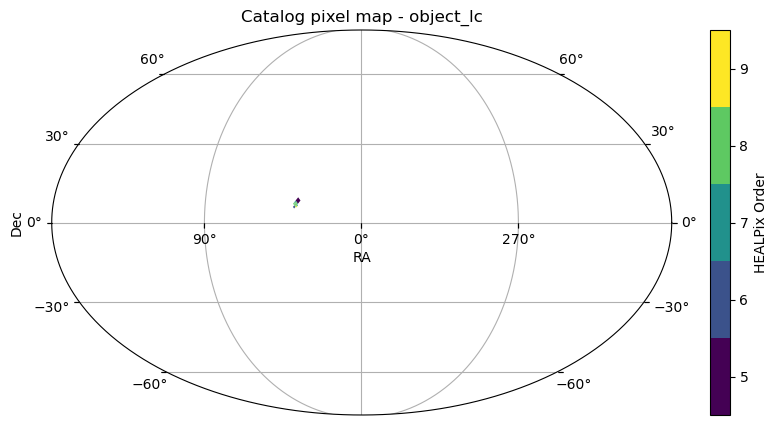

In [17]:
# Plot catalog
cat.plot_pixels();

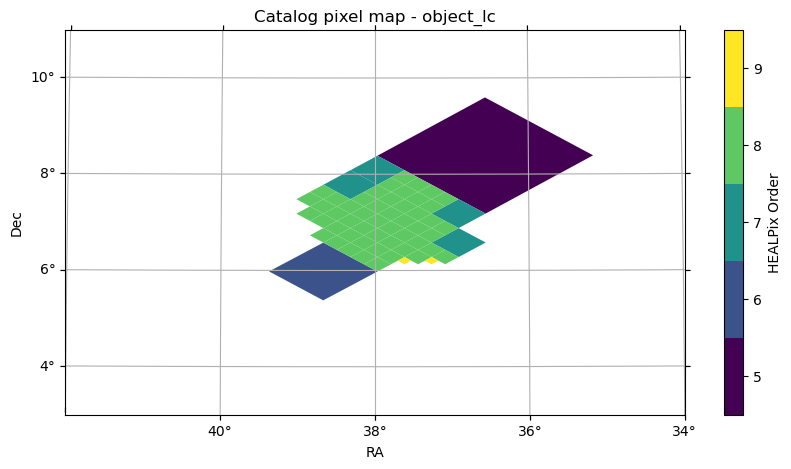

In [18]:
# Plot zoomed catalog
import astropy.units as u
fov = (8 * u.deg, 8 * u.deg)
center = SkyCoord(38 * u.deg, 7 * u.deg)
fig, ax = cat.plot_pixels(projection="AIT", fov=fov, center=center);

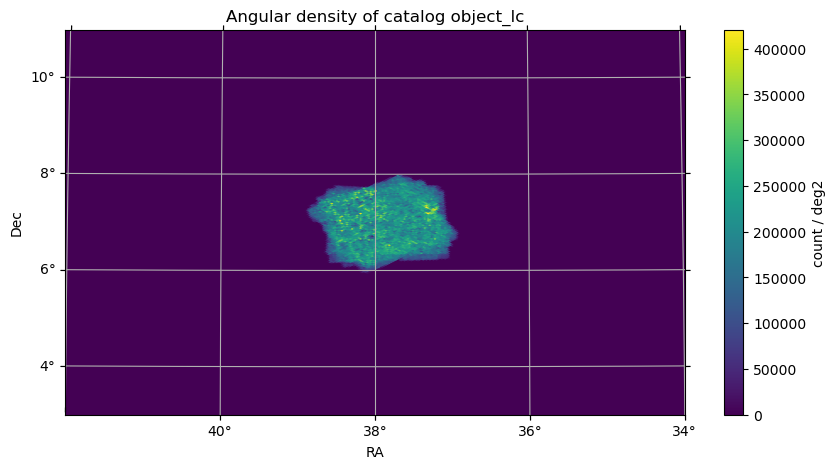

In [19]:
# Plot density
import hats
hats.inspection.plot_density(cat.hc_structure, ec='face', projection="AIT", fov=fov, center=center);

In [20]:
# Map a function

# The mappable function takes in a dataframe that represents a partition.
# It returns a dataframe.
def g_minus_r_mapper(df):
    import numpy as np
    df['g_minus_r_mag'] = -np.log(df['g_psfFlux'] / df['r_psfFlux'])
    return df

cat = cat.map_partitions(g_minus_r_mapper)


In [21]:
# Check catalog before computing
cat.head()

,g_psfFlux,g_psfFluxErr,r_psfFlux,r_psfFluxErr,coord_ra,coord_dec,g_minus_r_mag
_healpix_29,,,,,,,
9195875808926578,1274.516846,97.626991,2462.434326,179.295883,38.112638,6.055018,0.658583
9195880698798110,101.968376,75.836388,779.184998,175.399323,38.107254,6.055974,2.033586
9195883228609832,223.450165,75.524231,851.002747,173.62944,38.112592,6.058814,1.337227
9195883532105479,89.467979,75.252007,1707.087524,174.774734,38.113882,6.060315,2.948663
9195884147047980,550.610413,76.316589,1112.894287,175.488525,38.110133,6.059977,0.703692


In [22]:
# Compute catalog and write to disk
cat.write_catalog('dp2_example_cat', overwrite=True)

In [23]:
# Compute catalog to dataframe
df = cat.compute()

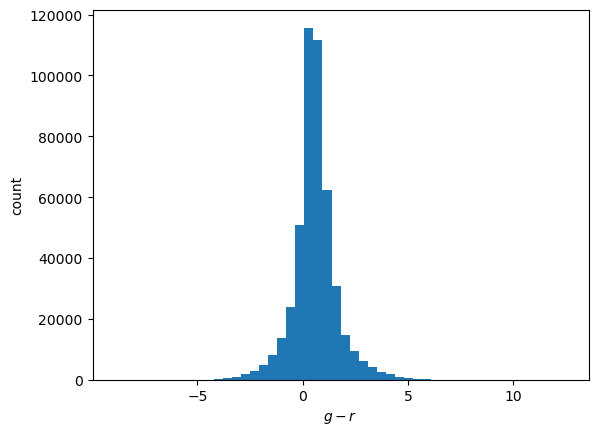

In [25]:
import numpy as np
plt.hist(df['g_minus_r_mag'], bins=50);
plt.xlabel('$g-r$');
plt.ylabel('count');

In [26]:
# Read catalog from disk
cat = lsdb.open_catalog('dp2_example_cat')

In [27]:
# Crossmatch
gaia_cat = lsdb.open_catalog('https://data.lsdb.io/hats/gaia_dr3',
                            columns=['parallax', 'pmra', 'pmdec'])
gaia_cat

,parallax,pmra,pmdec,ra,dec
npartitions=2016,,,,,
"Order: 2, Pixel: 0",double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow]
"Order: 2, Pixel: 1",...,...,...,...,...
...,...,...,...,...,...
"Order: 3, Pixel: 766",...,...,...,...,...
"Order: 3, Pixel: 767",...,...,...,...,...


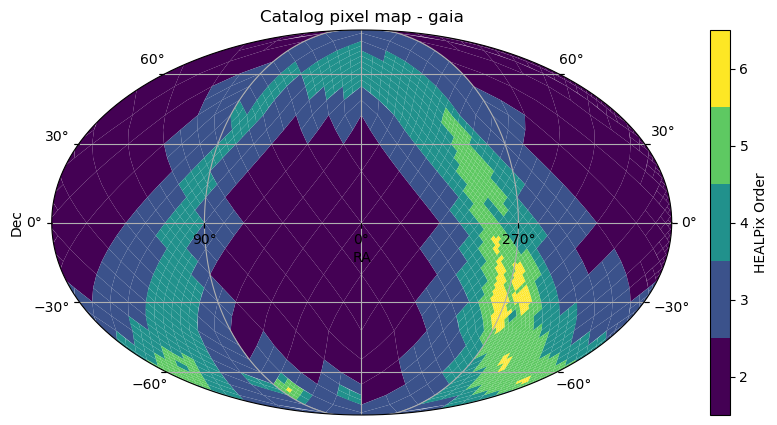

In [30]:
gaia_cat.plot_pixels();

In [31]:
x_cat = cat.crossmatch(gaia_cat, suffix_method='overlapping_columns')

In [32]:
x_cat.head()

,g_psfFlux,g_psfFluxErr,r_psfFlux,r_psfFluxErr,coord_ra,coord_dec,g_minus_r_mag,parallax,pmra,pmdec,ra,dec,_dist_arcsec
_healpix_29,,,,,,,,,,,,,
9195975821955136,20678.574219,98.712624,59545.597656,266.540833,38.099862,6.062018,1.057644,<NA>,<NA>,<NA>,38.099866,6.062018,0.013663
9196022386857338,17626.976562,97.64463,65017.363281,277.094177,38.089481,6.079753,1.305224,1.281341,9.847827,-5.071433,38.089454,6.079769,0.110354
9196172614850268,7408.179688,67.391457,25701.205078,207.730148,38.159999,6.101963,1.243953,1.356362,-1.5467,-8.540179,38.160002,6.101985,0.079138
9196187879039479,6943.67627,74.461746,20820.986328,204.725708,38.121986,6.08271,1.09813,<NA>,<NA>,<NA>,38.121987,6.08271,0.004793
9196205951626645,865840.875,365.774902,1624888.25,860.297241,38.125687,6.090892,0.629493,1.109139,10.772333,-13.440171,38.125662,6.090929,0.160776


/opt/lsst/software/stack/conda/envs/lsst-scipipe-13.0.0-exact/lib/python3.13/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


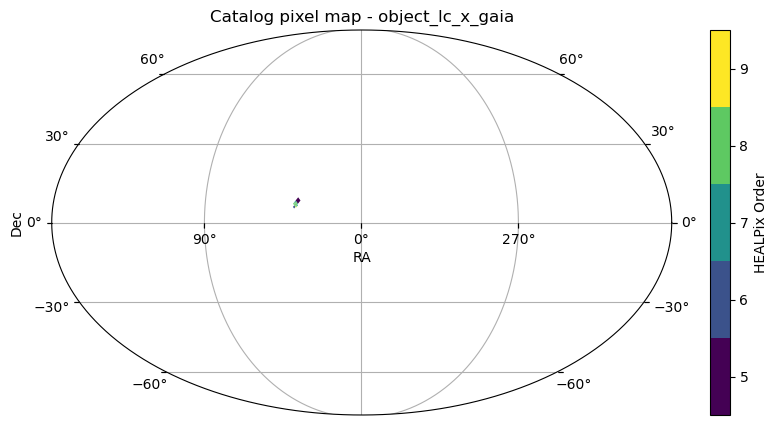

In [33]:
x_cat.plot_pixels();

In [34]:
x_df = x_cat.compute()

In [35]:
x_df

,g_psfFlux,g_psfFluxErr,r_psfFlux,r_psfFluxErr,coord_ra,coord_dec,g_minus_r_mag,parallax,pmra,pmdec,ra,dec,_dist_arcsec
_healpix_29,,,,,,,,,,,,,
9195975821955136,20678.574219,98.712624,59545.597656,266.540833,38.099862,6.062018,1.057644,<NA>,<NA>,<NA>,38.099866,6.062018,0.013663
9196022386857338,17626.976562,97.64463,65017.363281,277.094177,38.089481,6.079753,1.305224,1.281341,9.847827,-5.071433,38.089454,6.079769,0.110354
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1258720713607169164,69500.476562,249.711075,129607.789062,348.57959,36.940468,6.836284,0.623179,0.046762,-0.670993,-2.59996,36.940477,6.836293,0.048372
1258720739477609080,2995.177734,125.194969,10962.962891,189.426453,36.946959,6.850663,1.297519,<NA>,<NA>,<NA>,36.946945,6.850656,0.054063


<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_70/753833943.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\pi$ (Gaia)');


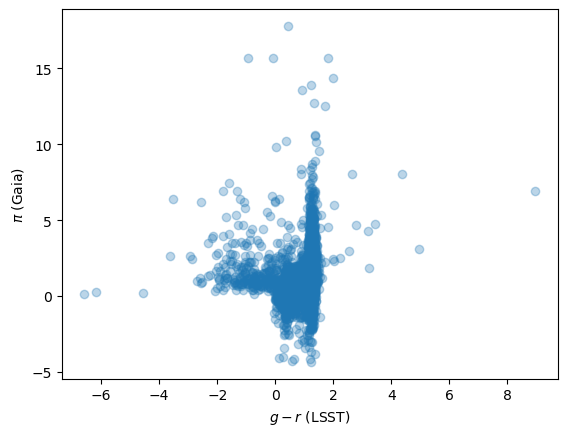

In [36]:
plt.scatter(x_df['g_minus_r_mag'], x_df['parallax'], alpha=0.3);
plt.xlabel('$g-r$ (LSST)');
plt.ylabel('$\pi$ (Gaia)');

In [37]:
# Clean up
client.close()